# Week 9 Phase 1.19A — integrity, posterior calibration, and monotonic structure

This notebook reads the frozen audit artifacts. It does not run an active-learning experiment.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Markdown, Image
OUT=Path('../../outputs/week9_phase1_19a_integrity_posterior_monotonicity_audit')
assert OUT.exists()
print('Frozen Phase 1.19A artifacts:', OUT.resolve())

Frozen Phase 1.19A artifacts: C:\Users\ozgur\Documents\thesis-week9-phase1-19a-integrity-posterior-monotonicity-audit\outputs\week9_phase1_19a_integrity_posterior_monotonicity_audit


## 1. Frozen gate and configurations

Groups are exact combinations of verified XI/XF/XL/TE folder fields. The window flag compares TE with 90% of the verified x-domain traversal time.

,configuration_group,N,keyholes,conduction,keyhole_prevalence,XI_m,XF_m,XL_m,TE_s,domain_max_x_m,...,P_max,VX_min,VX_median,VX_max,LS_min,LS_median,LS_max,ST_min,ST_median,ST_max
0,CFG_MAIN,364,70,294,0.192308,0.0002,0.0014,0.0012,0.00210,0.001212,...,449.762376,0.203591,0.639609,0.998321,0.000040,0.000064,0.000090,300.016424,352.59456,399.817711
1,CFG_NEGATIVE_XI_SHORT,27,3,24,0.111111,-0.0002,0.0012,0.0014,0.00125,0.001212,...,149.254341,0.201002,0.596650,0.986228,0.000045,0.000045,0.000045,300.000000,300.00000,300.000000
2,CFG_POSITIVE_XI_SHORT,14,0,14,0.000000,0.0002,0.0014,0.0012,0.00125,0.001212,...,248.695097,0.201685,0.582166,0.887957,0.000046,0.000067,0.000079,302.148971,346.01379,398.207664


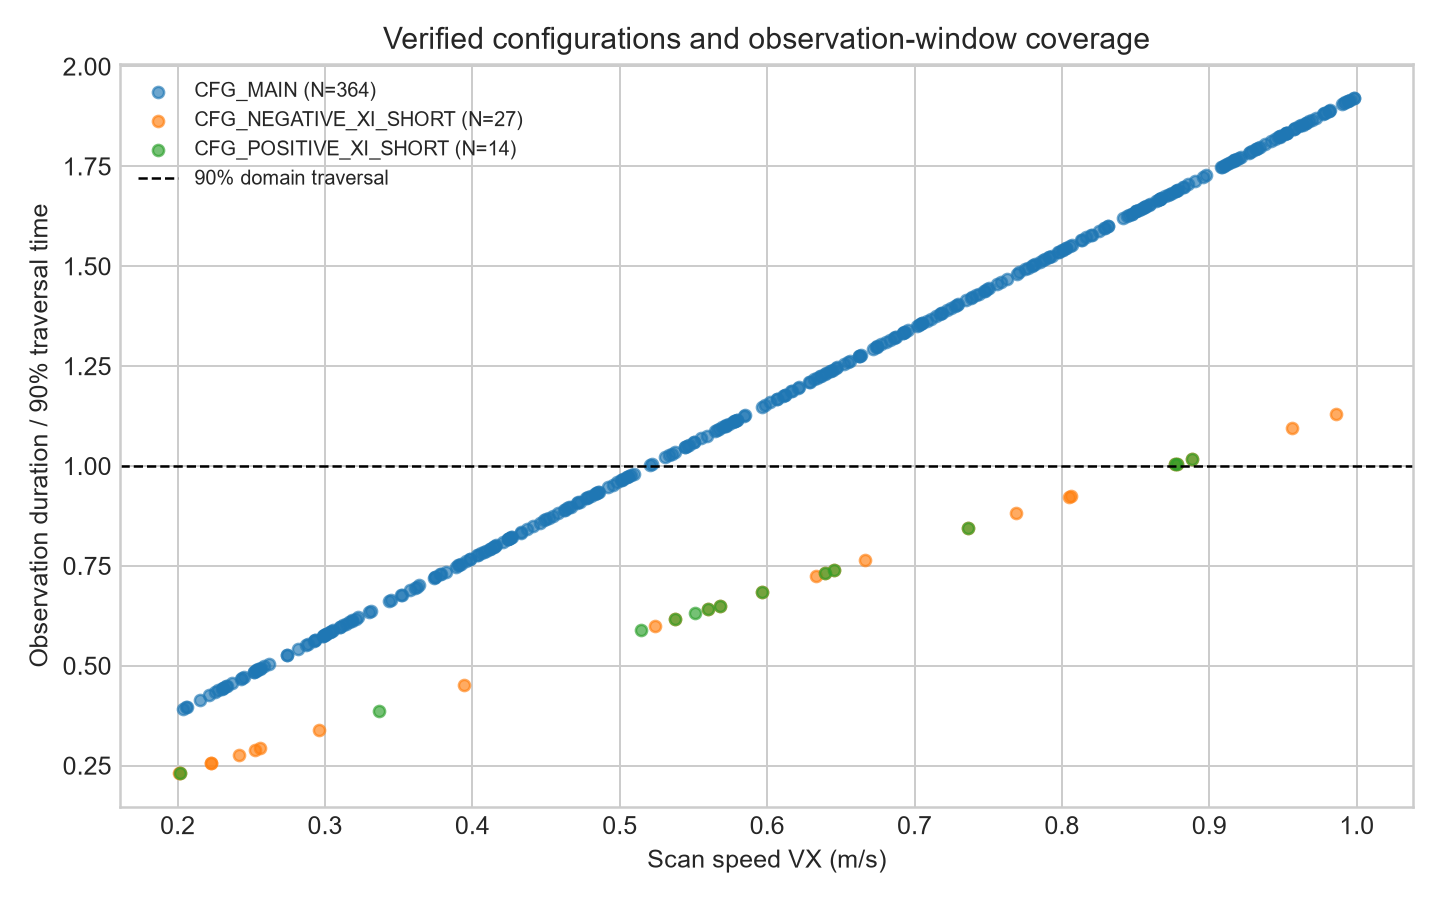

In [2]:
display(pd.read_csv(OUT/'configuration_summary.csv'))
display(Image(filename=str(OUT/'figures/01_configuration_observation_window.png')))

## 2. Continuous-depth censoring

The threshold is derived without labels from the largest upper-tail gap in the main configuration. It is an empirical terminal-pile rule, not a universal 295 µm assumption.

,configuration_group,depth_censoring_class,N,keyholes,conduction,min_depth_um,median_depth_um,max_depth_um,threshold_um,lower_nonpile_um,upper_pile_um
0,CFG_MAIN,likely_domain_floor_censored,39,39,0,300.70840,302.814800,311.99990,294.18005,287.6517,300.7084
1,CFG_MAIN,uncensored,325,31,294,19.03058,62.834110,287.65170,294.18005,287.6517,300.7084
2,CFG_NEGATIVE_XI_SHORT,uncensored,27,3,24,23.18574,47.465920,182.72740,294.18005,287.6517,300.7084
3,CFG_POSITIVE_XI_SHORT,uncensored,14,0,14,27.19738,62.372025,71.39363,294.18005,287.6517,300.7084


,scenario,regime,N_mean,MAE_um,RMSE_um,median_absolute_relative_error,repeat_blocks,model
0,D0_original,Conduction,332.0,21.715181,28.133068,0.310196,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
1,D0_original,Keyhole,73.0,59.601583,68.229372,0.231110,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
2,D0_original,all,405.0,28.544088,38.573702,0.282191,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
3,D1_uncensored_evaluation,Conduction,332.0,21.715181,28.133068,0.310196,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
4,D1_uncensored_evaluation,Keyhole,34.0,51.391072,61.000155,0.261290,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
5,D1_uncensored_evaluation,all,366.0,24.471958,32.613788,0.303864,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
6,D2_uncensored_train_and_evaluate,Conduction,332.0,9.225924,12.593803,0.116795,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
7,D2_uncensored_train_and_evaluate,Keyhole,34.0,57.355974,70.631129,0.326624,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."
8,D2_uncensored_train_and_evaluate,all,366.0,13.697022,24.643978,0.125902,20,"fixed Ridge(alpha=1) on standardized P,VX,LS,S..."


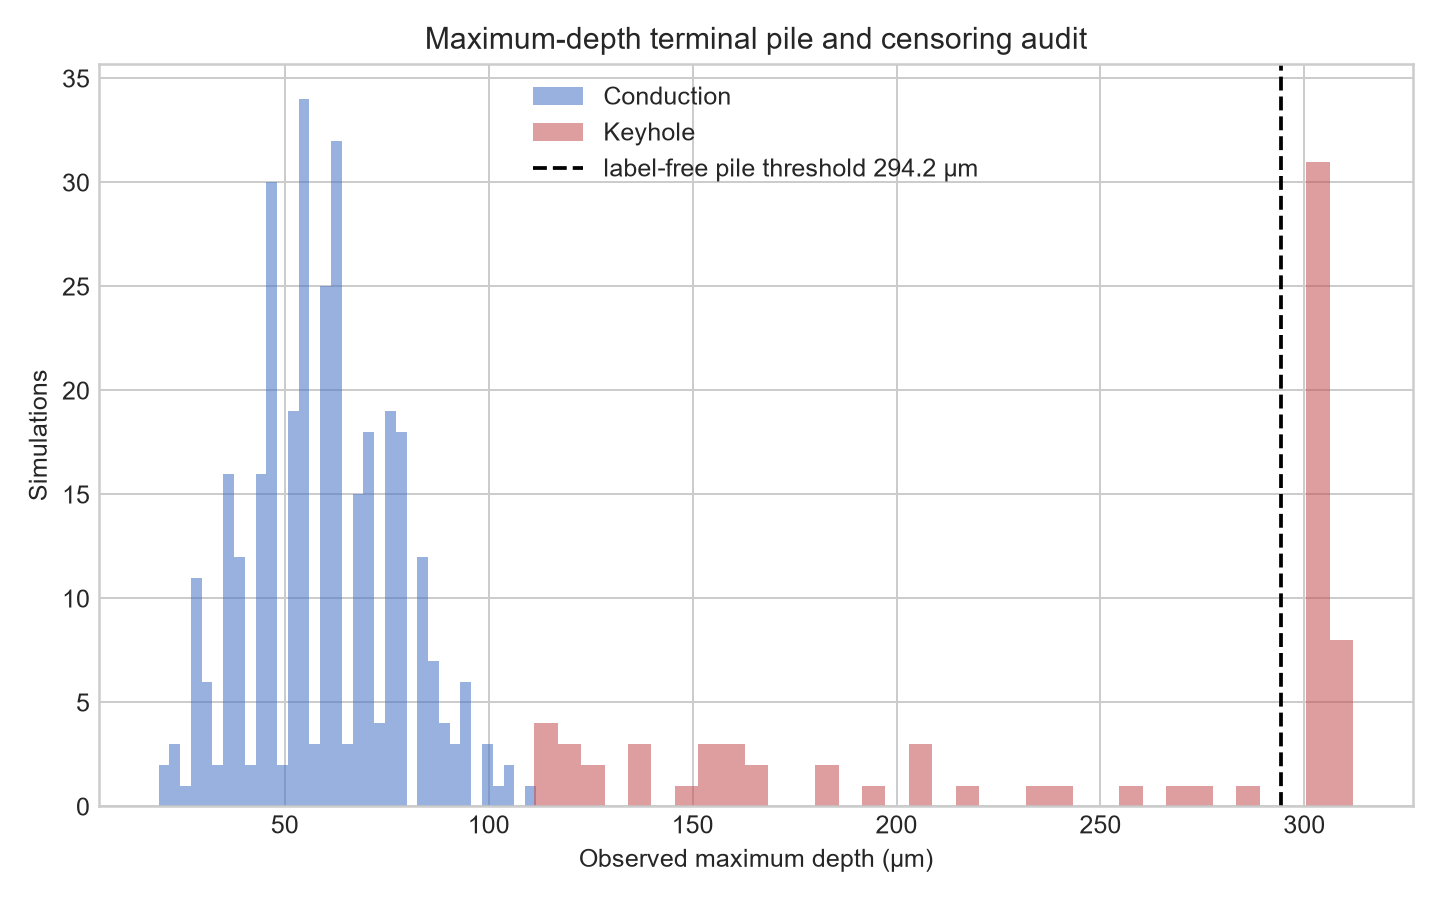

In [3]:
display(pd.read_csv(OUT/'depth_censoring_summary.csv'))
display(pd.read_csv(OUT/'depth_sensitivity.csv'))
display(Image(filename=str(OUT/'figures/02_depth_censoring.png')))

## 3. Stage-1 exact separation and held-out calibration

Large logits are not enough to claim miscalibration. We combine exact 1D separation checks with held-out Brier, log loss, ECE, and probability concentration.

,budget,snapshots,perfect_h_separation_N,perfect_h_separation_fraction,coefficient_median,coefficient_q10,coefficient_q90,coefficient_max,max_abs_pool_logit_median,median_abs_pool_logit_median,fraction_pool_abs_gt10_mean,pool_abs_lt1_median_N
0,16,100,55,0.55,20.977568,2.903717,80.251947,577.825253,48.456202,14.952875,0.471721,11.0
1,20,100,39,0.39,38.584906,3.119461,371.818810,731.782018,118.014297,39.598011,0.547303,2.0
2,24,100,9,0.09,8.586177,2.907133,160.453001,745.050275,25.583486,8.781634,0.465500,9.5
3,32,100,2,0.02,6.055486,2.674936,14.415347,225.186556,21.692657,7.364249,0.329110,7.0
4,40,100,1,0.01,4.431329,2.376464,7.661349,203.865322,15.820334,5.705309,0.181585,3.0
5,60,100,1,0.01,3.766329,2.509710,5.183794,192.662910,16.155108,6.080200,0.169167,0.0
6,80,100,0,0.00,3.965790,3.160082,4.724550,5.829413,18.232341,6.960809,0.219508,0.0


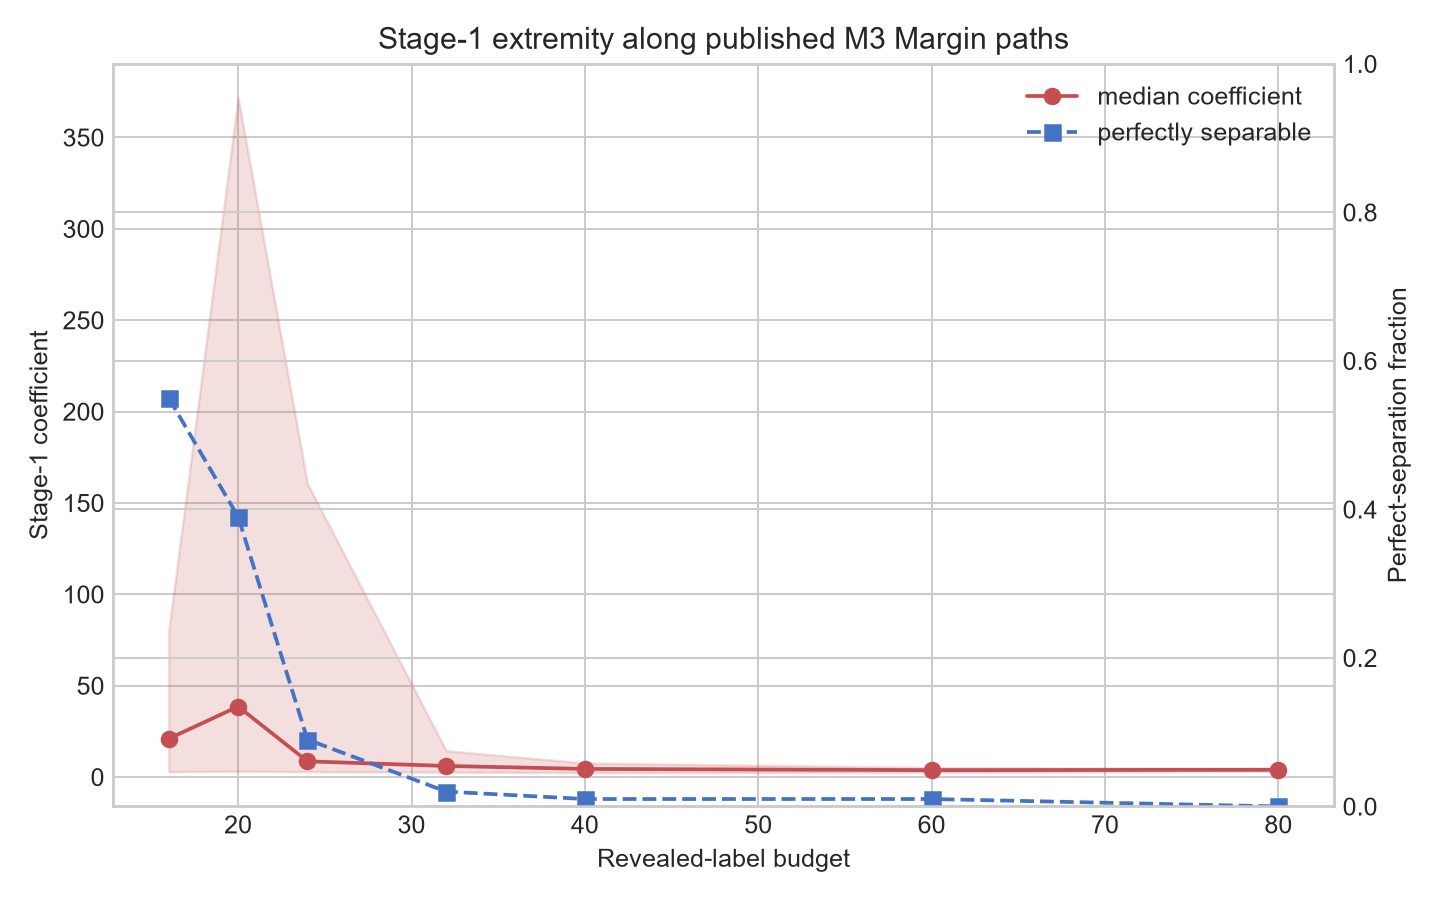

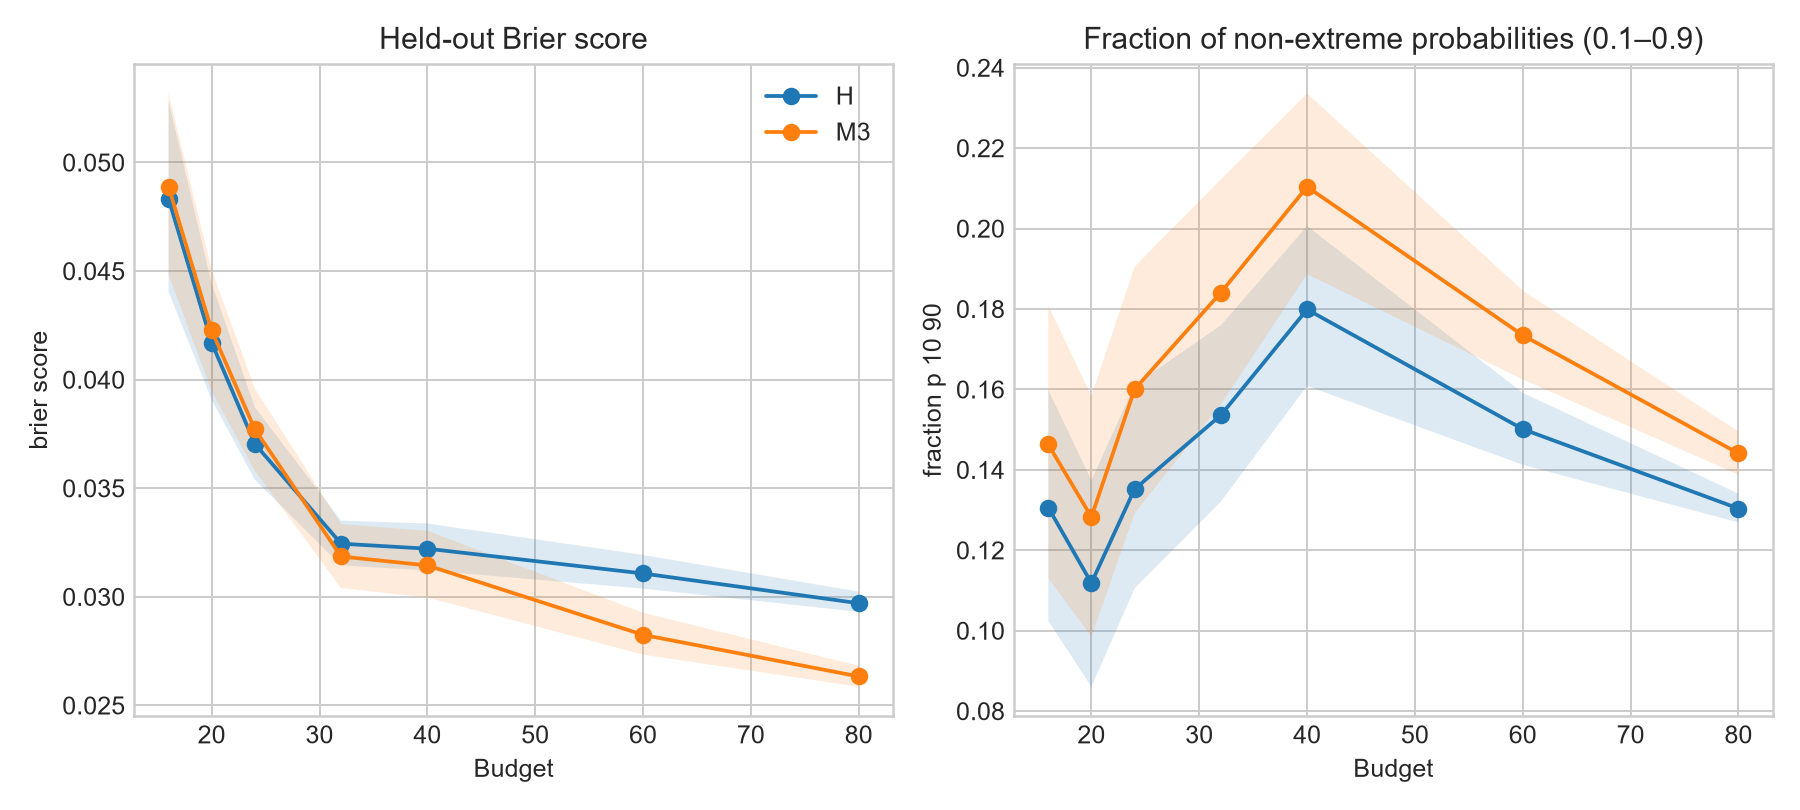

In [4]:
sep=pd.read_csv(OUT/'stage1_separation_summary.csv'); display(sep)
display(Image(filename=str(OUT/'figures/03_stage1_separation.png')))
display(Image(filename=str(OUT/'figures/04_h_m3_calibration.png')))

## 4. Monotone partial order

Primary order: power increases, speed decreases, and spot size decreases toward Keyhole; ST is ignored. Directed and unique-unordered pair counts are both shown.

,population,N,keyholes,conduction,comparable_directed_pairs,comparable_unique_unordered_pairs,all_unique_unordered_pairs,comparable_pair_fraction,violations,violation_rate_directed,definition
0,full_405,405,73,332,22050,22050,81810,0.269527,3,0.000136,"j more Keyhole-favouring iff P_j>=P_i, VX_j<=V..."


,population,N,keyholes,conduction,comparable_directed_pairs,comparable_unique_unordered_pairs,all_unique_unordered_pairs,comparable_pair_fraction,violations,violation_rate_directed,definition
0,main_configuration_only,364,70,294,19491,19491,66066,0.295023,3,0.000154,"j more Keyhole-favouring iff P_j>=P_i, VX_j<=V..."


,violation_id,role,population_row_index,simulation_id,truth,P,VX,LS,ST,h,configuration_group,observation_duration_s,observation_ends_before_90pct_domain,max_depth_um,keyhole_frame_count,first_keyhole_timestep,B1,q20_test_fraction,q30_test_fraction
0,1,less_favouring_Keyhole,150,P-423p354289604_VX-0p98992750487_LS-4p35270321...,1,423.354290,0.989928,0.000044,379.923005,1.481712e+09,CFG_MAIN,0.0021,False,111.19820,4,20637.0,0.776315,1.0,1.0
1,1,more_favouring_Conduction,157,P-441p843471056_VX-0p982124766198_LS-4p0987534...,0,441.843471,0.982125,0.000041,327.495508,1.699055e+09,CFG_MAIN,0.0021,False,105.08480,0,NaN,0.443566,1.0,1.0
2,2,less_favouring_Keyhole,152,P-429p223744451_VX-0p993777087019_LS-4p4993950...,1,429.223744,0.993777,0.000045,337.477092,1.426619e+09,CFG_MAIN,0.0021,False,115.89620,3,19757.0,0.443566,1.0,1.0
3,2,more_favouring_Conduction,157,P-441p843471056_VX-0p982124766198_LS-4p0987534...,0,441.843471,0.982125,0.000041,327.495508,1.699055e+09,CFG_MAIN,0.0021,False,105.08480,0,NaN,0.443566,1.0,1.0
4,3,less_favouring_Keyhole,287,P-228p959503311_VX-0p480404321045_LS-6p0796636...,1,228.959503,0.480404,0.000061,336.115874,6.968445e+08,CFG_MAIN,0.0021,True,124.05370,47,90647.0,0.636824,1.0,1.0
5,3,more_favouring_Conduction,288,P-229p384485496_VX-0p374546448601_LS-5p6189268...,0,229.384485,0.374546,0.000056,346.005476,8.898793e+08,CFG_MAIN,0.0021,True,82.94931,0,NaN,0.626788,1.0,1.0


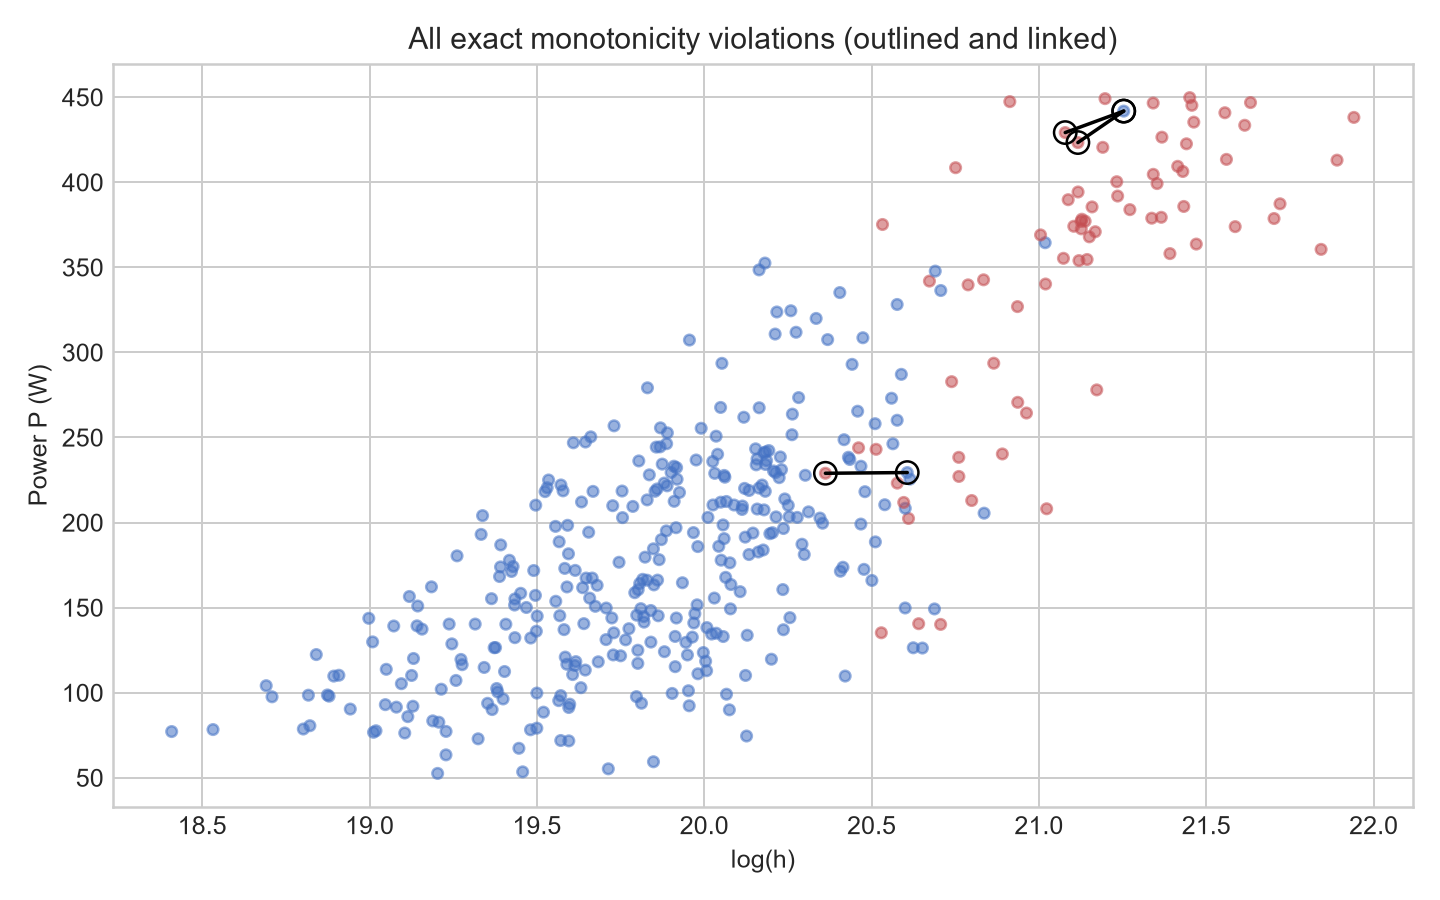

In [5]:
display(pd.read_csv(OUT/'monotonicity_pair_summary.csv'))
display(pd.read_csv(OUT/'monotonicity_main_config_summary.csv'))
display(pd.read_csv(OUT/'monotonicity_violations.csv'))
display(Image(filename=str(OUT/'figures/05_monotonicity_violations.png')))

## 5. Poset usefulness and safety

The oracle hard-propagation diagnostic uses all labels retrospectively. It is not an algorithm or label-saving estimate.

,population,N,predecessors_median,predecessors_q10,predecessors_q90,successors_median,successors_q10,successors_q90,minimal_elements,maximal_elements,exact_antichain_width_via_Dilworth,KH_reveal_implied_unknown_median,C_reveal_implied_unknown_median,KH_reveal_implied_unknown_q90,C_reveal_implied_unknown_q90
0,full_405,405,27.0,2.0,154.0,39.0,4.0,128.2,22,11,93,39.0,27.0,128.2,154.0


,diagnostic,source_labels,implication_edges,unique_target_label_assignments,wrong_implication_edges,unique_wrong_target_label_assignments,contradictory_target_points,active_learning_or_label_saving_claim,warning
0,oracle_retrospective_hard_propagation,405,10462,341,6,5,0,False,uses all known labels retrospectively; not a p...


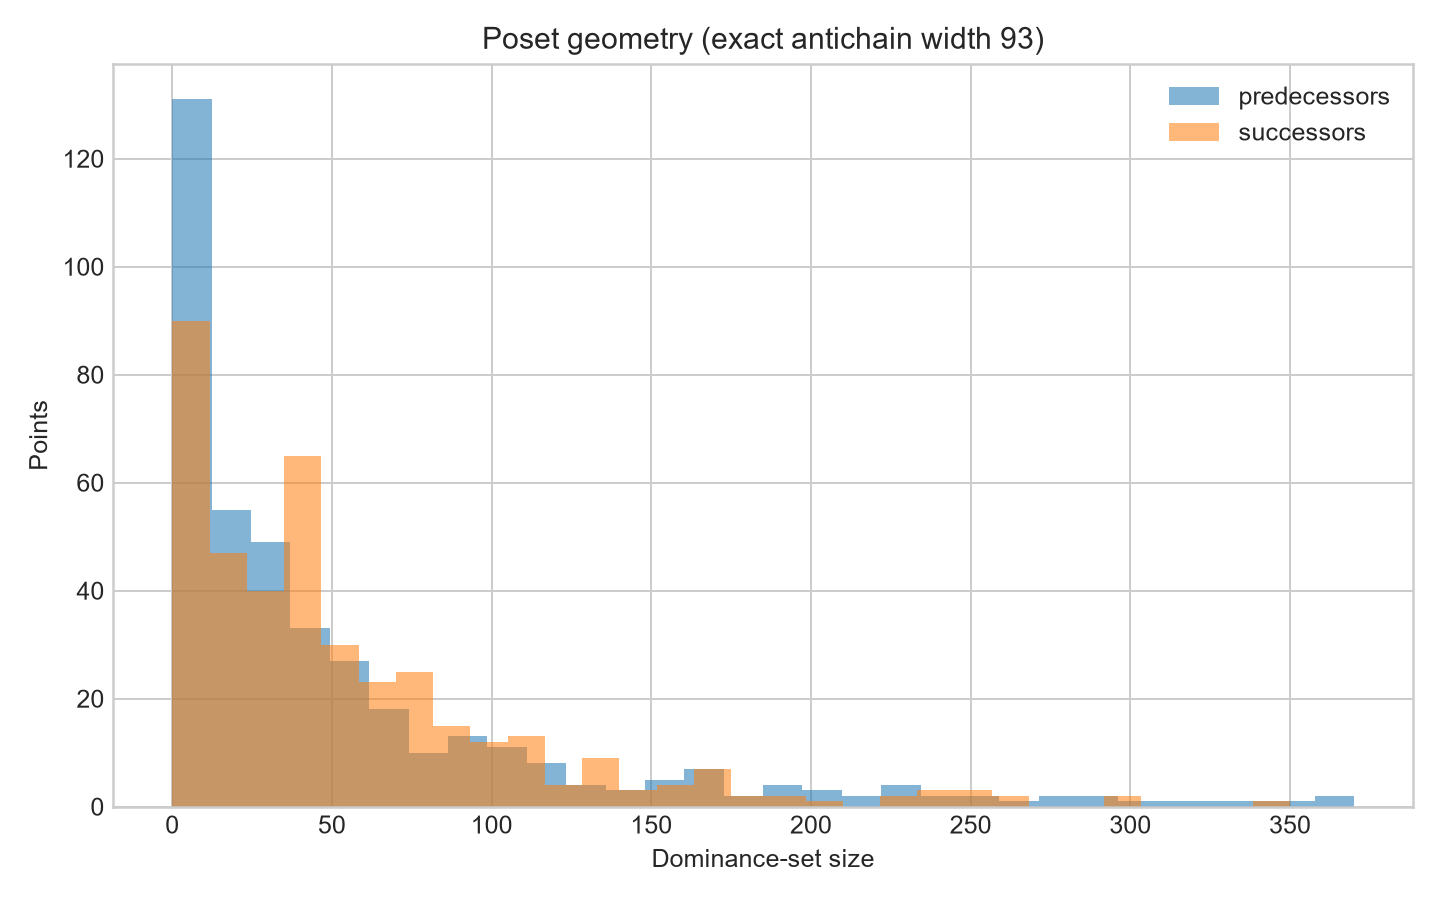

In [6]:
display(pd.read_csv(OUT/'poset_geometry_summary.csv'))
display(pd.read_csv(OUT/'monotonicity_retrospective_safety.csv'))
display(Image(filename=str(OUT/'figures/06_poset_structure.png')))

## 6. Mathematical applicability and decisions

In [7]:
display(Markdown((OUT/'letham_2022_applicability_memo.md').read_text(encoding='utf-8')))
for name in ['configuration','depth','stage1','monotonicity']:
    display({name: json.loads((OUT/f'{name}_decision.json').read_text())})
display({'next': json.loads((OUT/'next_method_gate.json').read_text())})

# Letham et al. (2022) applicability memo

Primary source: Benjamin Letham, Phillip Guan, Chase Tymms, Eytan Bakshy, and Michael Shvartsman, *Look-Ahead Acquisition Functions for Bernoulli Level Set Estimation*, AISTATS 2022, [PMLR paper and supplement](https://proceedings.mlr.press/v151/letham22a.html). Associated authors' code: [facebookresearch/bernoulli_lse](https://github.com/facebookresearch/bernoulli_lse/).

## Exact answers

1. **Likelihood.** The paper studies Bernoulli observations. It notes that classification GPs can use logit or probit links, but its derivation focuses on the **probit** model, `y ~ Bernoulli(Phi(f(x)))`. Its experiments use variational inference; the acquisition derivation only requires an approximate multivariate-normal posterior for the latent `f`.
2. **Primary derivation.** Probit, not logistic.
3. **Why the bivariate-normal closed form appears.** The probit likelihood is a Gaussian CDF. Integrating products of Gaussian CDF terms against the joint Gaussian latent posterior reduces to Gaussian integral identities involving `Phi`, Owen's T, and a standard bivariate-normal CDF. The full one-step latent posterior is still intractable, but the look-ahead **level-set membership probability** is analytic.
4. **Acquisitions.** GlobalSUR is the expected reduction in the reference-set sum of posterior level-set misclassification probabilities `min(pi,1-pi)`. GlobalMI replaces that loss with the sum of binary entropies `H_b(pi)`. EAVC is expected absolute change in estimated sublevel-set volume, computed from the reference-set sum of membership probabilities. GlobalSUR and GlobalMI are SUR-form objectives; EAVC is not a SUR objective.
5. **Analytically available quantities.** Under a probit link and an MVN latent posterior: predictive Bernoulli mean, variance of the transformed probability (via Owen's T), and the one-step look-ahead level-set membership posterior for both possible outcomes (via `Phi` and the bivariate-normal CDF). GlobalSUR, LocalSUR, GlobalMI, LocalMI, and EAVC then follow analytically once summed over a reference set.
6. **Direct application to current M3.** No. M3 uses a Bernoulli-**logistic** likelihood with a custom Laplace posterior and a training-fitted logistic physics mean. Replacing `Phi` by the logistic sigmoid does not preserve the Gaussian-CDF identities that create the closed form.
7. **Changes needed.** A direct use would require a probit M3 counterpart: probit Stage-1 physics mean or another explicitly defined latent mean, probit Bernoulli residual-GP likelihood, a validated MVN latent posterior approximation and cross-covariances, consistent latent threshold `gamma` (zero for probability 0.5), and implementation/parity tests for the paper's level-set-membership updates and reference-set GlobalSUR/GlobalMI/EAVC. Alternatively, logistic M3 would require a new controlled numerical approximation; it would not be the paper's closed-form method.

## Relation to Phase 1.18B

Phase 1.18B minimized expected finite-pool predictive-probability uncertainty based on `p(1-p)` after explicit hypothetical refits. That is not Letham et al.'s level-set membership misclassification loss, not its probit closed-form update, and not evidence about every Bernoulli LSE look-ahead acquisition. This memo is mathematical applicability analysis only; Phase 1.19A implements no Letham trajectory.


{'configuration': {'decision': 'CONFIGURATION_SENSITIVITY_REQUIRED',
  'guardrail': 'No relabeling and no causal confound claim; configuration was not randomized.',
  'reason': 'Three exact configurations are present (364 main, 41 non-main), and 167 observations end before 90% domain traversal; the main-configuration model-only sensitivity is therefore reported rather than treating configuration as negligible.'}}

{'depth': {'decision': 'DEPTH_CENSORING_CONFIRMED',
  'guardrail': 'This affects continuous-depth interpretation, not the frozen binary regime label.',
  'likely_censored_Keyhole': 39,
  'likely_censored_N': 39,
  'reason': 'A label-free upper-tail gap isolates 39 main-configuration depths in a dense terminal pile. Fixed Ridge RMSE changes from 38.574 um (D0) to 24.644 um (D2).'}}

{'stage1': {'decision': 'STAGE1_OVERCONFIDENCE_MIXED',
  'guardrail': 'This decision concerns probability uncertainty, not invalidation of M3 hard prediction quality.',
  'reason': 'At B16, 55.0% of revealed sets are perfectly separable and the median coefficient is 20.978; at B24 the separable fraction is 9.0%. Held-out B16 Brier is H=0.0483, M3=0.0489.'}}

{'monotonicity': {'decision': 'MONOTONIC_STRUCTURE_STRONG',
  'guardrail': 'Exact hard propagation is unsafe wherever the frozen labels violate the order; a future method must be soft/robust.',
  'reason': 'Full: 3/22050 violations (0.013605%) with 27.0% pair comparability. Main configuration: 3/19491.'}}

{'next': {'decision': 'NEXT_MONOTONE_POOL_LSE',
  'no_new_method_run_in_phase1_19a': True,
  'reason': "The partial order is directly and strongly supported. Letham's closed form is not directly applicable to logistic M3 and would first require a probit-model audit."}}

## Safe conclusion

This audit identifies integrity caveats, probability-separation behavior, and an almost-monotone pool structure. It creates no new active-learning trajectory and supports no sample-saving claim.